# Lesson 07: Neural Networks Walkthrough
## Medina County Career Center - Applications of Artificial Intelligence

**Objective:** Understand how neural networks work and build one in Python.

**By the end of this lesson, you will:**
- Explain what a neuron is and how weights work
- Understand forward pass and backpropagation (conceptually)
- Build a neural network using scikit-learn
- Use a **validation set** and **early stopping** to prevent overfitting
- Visualize the training loss curve and diagnose convergence
- Compare neural networks to linear regression
- Identify when to use neural networks


## How Neural Networks Work

### Part 1: The Neuron Analogy

Your brain has ~86 billion neurons. Each one:
1. **Receives signals** from other neurons
2. **Adds them up** (some signals are stronger/"weighted" than others)
3. **Fires or doesn't fire** based on whether the total exceeds a threshold

An artificial neuron does the same thing with numbers!

```
Biological Neuron          Artificial Neuron
  (soma)                        (node)
    ↑ receives              receives inputs
    |                        ↓
    | signal = weight ×     multiply by weights
    |              input    ↓
    | (dendrites)           sum them up
    ↑                        ↓
(axon fires if sum           apply activation
exceeds threshold)          function (threshold)
    ↓                        ↓
  send signal              output to next layer
```

### Part 2: Weights and Bias

Each connection has a **weight** - a number that gets multiplied by the input.

```
Inputs  |  Weights | Sum with bias |  Activation | Output
  x₁ ——————(w₁)——┐
             ├—————→[ Σ + b ]————————→[Activate?]—→ output
  x₂ ——————(w₂)——┘

Formula: output = activate( (x₁×w₁ + x₂×w₂ + ... ) + bias )
```

**During training:** The network learns the best weights to minimize error. Weights start random, then adjust thousands of times.

### Part 3: Layers and Architecture

Neurons organize into **layers**:

```
Input Layer       Hidden Layer        Output Layer
(raw data)        (learns patterns)   (prediction)

  cement ●                  ●
         |                 /|\            
  water  ●———————————————●  | ●—————————strength
         |                 \|/         
  age    ●                  ●
  
  (8 inputs)          (32 neurons)      (1 output)
```

**Input Layer:** Your raw data (concrete ingredients and curing age)

**Hidden Layers:** Learn increasingly complex patterns. More hidden layers = deeper network = can learn more complex patterns

**Output Layer:** Final prediction

**Example configurations:**
- `(10,)` = 1 hidden layer with 10 neurons
- `(32, 16)` = 2 hidden layers: 32 neurons, then 16 neurons
- `(100, 50, 25)` = 3 hidden layers: 100, 50, 25 neurons ("deeper learning"!)

### Part 4: How Training Works (Conceptual)

When a neural network trains, it repeats this cycle:

**1. Forward Pass**
```
Input Data → Apply weights → Activate → Prediction
```
The network makes a guess using current weights.

**2. Calculate Loss**
```
Loss = How wrong was the prediction?
Example: Predicted 45 MPa, actual was 42 MPa → Loss = 3 MPa (squared)
```

**3. Backpropagation**
```
Trace the error backwards through the network.
Figure out which weights caused the error.
Adjust them slightly.
```

**4. Repeat**
```
Do this thousands of times with different batches of training data.
```

It's like studying with practice tests: take a test, see what you got wrong, adjust your studying, take another test, repeat!

**Key idea:** We don't program the weights. The network **learns** them from data.

> We'll actually *see* this loss drop over iterations later in Part 4 of Sub-Lesson 07b when we plot the training loss curve.

### Part 5: TensorFlow Playground (Hands-On)

**Visit:** [playground.tensorflow.org](https://playground.tensorflow.org)

This website lets you visually build and train neural networks without writing code!

#### Experiment 1: Simple Dataset
1. Make sure the **circle dataset** is selected (bottom left)
2. Set hidden layers to just **1 layer with 2 neurons**
3. Click **Play** and watch it train
4. **Question:** Did 2 neurons learn the circle pattern? Why or why not?

#### Experiment 2: Add More Neurons
1. Stop the training
2. Increase to **1 layer with 8 neurons**
3. Click **Play** again
4. **Question:** Does it learn faster and better than 2 neurons?

#### Experiment 3: Add Hidden Layers
1. Click the **+** button to add another hidden layer
2. Set to **2 layers: 8 neurons each**
3. Click **Play**
4. **Question:** Is the network learning better? Faster? Why might extra layers help?

#### Experiment 4: The Hard Problem
1. Switch to the **spiral dataset** (the hardest one!)
2. Try **1 layer with 5 neurons** - does it learn?
3. Increase to **2 layers with 16 neurons each** - better?
4. **Question:** Why does the spiral need a more complex network?

**Key observations:**
- More neurons = more capacity to learn complex patterns
- More layers = can learn deeper abstractions
- But too many = slow training, overfitting, wasted computation
- Different problems need different architectures!

## Neural Networks in Python

### Part 1: Setup and Load Data

Today we're predicting the **compressive strength of concrete** (in MPa) from its ingredients and how long it has cured.

Why concrete? The researcher who collected this data — I-Cheng Yeh, 1998 — specifically used **neural networks** because he found the relationship between strength and the inputs is "highly nonlinear." That makes it a great test case for comparing a neural network against simpler models.

**Inputs (8 features, all in kg per cubic meter of mix except age):**
- `cement` — main binder
- `slag` — blast furnace slag (supplementary binder)
- `fly_ash` — coal ash (supplementary binder)
- `water`
- `superplasticizer` — admixture that improves flow without adding water
- `coarse_aggregate` — large stones
- `fine_aggregate` — sand
- `age` — days of curing (1 to 365)

**Target:** `strength` in megapascals (MPa)

In [ ]:
# If ucimlrepo isn't installed yet, uncomment and run this once:
# %pip install ucimlrepo

In [1]:
# Import all the libraries we need
import pandas as pd  # pandas = work with data tables (like Excel in Python)
import numpy as np  # numpy = math and arrays
import matplotlib.pyplot as plt  # for plotting the loss curve
from sklearn.model_selection import train_test_split  # split data into train/test
from sklearn.preprocessing import StandardScaler  # scale features to similar range
from sklearn.neural_network import MLPRegressor  # neural network for predictions
from sklearn.linear_model import LinearRegression  # for comparison
from sklearn.metrics import r2_score, mean_absolute_error  # evaluate performance
import warnings
warnings.filterwarnings('ignore')  # suppress warning messages

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the Concrete Compressive Strength dataset
# Primary path: fetch from UCI directly using the official ucimlrepo package.
# Fallback path: if we're offline, read a local concrete.csv file
# (put concrete.csv in the same folder as this notebook).

try:
    from ucimlrepo import fetch_ucirepo
    concrete = fetch_ucirepo(id=165)  # id=165 is Concrete Compressive Strength
    concreteData = concrete.data.features.copy()
    concreteData['strength'] = concrete.data.targets.iloc[:, 0]
    print("Loaded from UCI repository.")
except Exception as e:
    print(f"UCI fetch failed ({e}). Falling back to local concrete.csv")
    concreteData = pd.read_csv('concrete.csv')

# Rename columns to short, consistent names regardless of source
concreteData.columns = [
    'cement', 'slag', 'fly_ash', 'water', 'superplasticizer',
    'coarse_aggregate', 'fine_aggregate', 'age', 'strength'
]

print(f"\nData loaded! Shape: {concreteData.shape}")
print("\nFirst few rows:")
print(concreteData.head())

Loaded from UCI repository.

Data loaded! Shape: (1030, 9)

First few rows:
   cement   slag  fly_ash  water  superplasticizer  coarse_aggregate  \
0   540.0    0.0      0.0  162.0               2.5            1040.0   
1   540.0    0.0      0.0  162.0               2.5            1055.0   
2   332.5  142.5      0.0  228.0               0.0             932.0   
3   332.5  142.5      0.0  228.0               0.0             932.0   
4   198.6  132.4      0.0  192.0               0.0             978.4   

   fine_aggregate  age  strength  
0           676.0   28     79.99  
1           676.0   28     61.89  
2           594.0  270     40.27  
3           594.0  365     41.05  
4           825.5  360     44.30  


In [3]:
# Prepare features (X) and target (y)
# X = inputs: all 8 mixture ingredients + age
# y = what we're predicting: compressive strength in MPa

X = concreteData.drop(columns='strength')  # features
y = concreteData['strength']                # target

print(f"Features X shape: {X.shape}")
print(f"Target y shape: {y.shape}")
print(f"\nFeature statistics:")
print(X.describe().round(1))
print(f"\nStrength range: {y.min():.1f} to {y.max():.1f} MPa")

Features X shape: (1030, 8)
Target y shape: (1030,)

Feature statistics:
       cement    slag  fly_ash   water  superplasticizer  coarse_aggregate  \
count  1030.0  1030.0   1030.0  1030.0            1030.0            1030.0   
mean    281.2    73.9     54.2   181.6               6.2             972.9   
std     104.5    86.3     64.0    21.4               6.0              77.8   
min     102.0     0.0      0.0   121.8               0.0             801.0   
25%     192.4     0.0      0.0   164.9               0.0             932.0   
50%     272.9    22.0      0.0   185.0               6.4             968.0   
75%     350.0   143.0    118.3   192.0              10.2            1029.4   
max     540.0   359.4    200.1   247.0              32.2            1145.0   

       fine_aggregate     age  
count          1030.0  1030.0  
mean            773.6    45.7  
std              80.2    63.2  
min             594.0     1.0  
25%             731.0     7.0  
50%             779.5    28.0  


In [4]:
# Split data into training and test sets
# Training set = teach the network (80% of data)
# Test set = see how it performs on new data (20% of data)
X_train, X_test, y_train, y_test = train_test_split(
    X,              # features
    y,              # target
    test_size=0.2,  # use 20% for testing
    random_state=42 # for reproducibility
)

print(f"Training set: {X_train.shape[0]} examples")
print(f"Test set: {X_test.shape[0]} examples")

Training set: 824 examples
Test set: 206 examples


### Part 2: Why Scale Data? (CRITICAL for Neural Networks!)

Neural networks learn by adjusting weights. If inputs have **very different scales**, training becomes slow and unstable.

**Look at our concrete features:**
- Cement: roughly 100–540 kg/m³
- Superplasticizer: roughly 0–32 kg/m³
- Age: 1–365 days

The network would struggle because one unit of "cement" means something very different numerically than one unit of "superplasticizer."

**StandardScaler solution:**
- Transform all features so mean = 0, standard deviation = 1
- All features on similar scale: roughly -2 to +2
- Network learns much faster and better!

This is not optional - neural networks NEED scaled data!

In [5]:
# Create a StandardScaler
# This learns the mean and std dev from training data
scaler = StandardScaler()

# Fit scaler on TRAINING data only, then transform
# (Never fit scaler on test data - that's data leakage!)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # use same scaling

print("Before scaling (first training example):")
print(f"  {X_train.iloc[0].values.round(2)}")
print(f"  Column means:    {X_train.mean().values.round(2)}")
print(f"  Column std devs: {X_train.std().values.round(2)}")

print("\nAfter scaling (first training example):")
print(f"  {X_train_scaled[0].round(2)}")
print(f"  Column means:    {X_train_scaled.mean(axis=0).round(2)}")
print(f"  Column std devs: {X_train_scaled.std(axis=0).round(2)}")
print("\nNotice: mean is ~0, std dev is ~1. Much better for neural networks!")

Before scaling (first training example):
  [158.6 148.9 116.  175.1  15.  953.3 719.7  28. ]
  Column means:    [283.36  74.37  53.16 181.8    6.16 973.55 772.11  44.66]
  Column std devs: [107.54  86.98  64.    21.32   5.97  78.69  80.98  60.48]

After scaling (first training example):
  [-1.16  0.86  0.98 -0.31  1.48 -0.26 -0.65 -0.28]
  Column means:    [ 0.  0.  0.  0. -0.  0. -0. -0.]
  Column std devs: [1. 1. 1. 1. 1. 1. 1. 1.]

Notice: mean is ~0, std dev is ~1. Much better for neural networks!


### Part 3: Build and Train the Neural Network

In [6]:
# Create a neural network model
# MLPRegressor = Multi-Layer Perceptron Regressor (fancy name for neural network)
#
# NEW in this version: we turn on EARLY STOPPING.
#   early_stopping=True     -> sklearn carves a small chunk off our training data
#                              to use as a validation set during training.
#   validation_fraction     -> what fraction of training data to hold out for
#                              that validation check (15% here).
#   n_iter_no_change=20     -> if validation score doesn't improve for 20
#                              iterations in a row, training STOPS early.
#                              The model also rolls back to the BEST weights
#                              it saw, not the final (possibly worse) ones.
#
# This is how we prevent the network from over-training and memorizing noise.

nnModel = MLPRegressor(
    hidden_layer_sizes=(32, 16),  # 2 hidden layers: 32 neurons, then 16
    max_iter=5000,                # generous cap - early stopping will halt us first
    solver='adam',                # this is the algorithm that updates the weights, and gives us a loss curve we can plot
    early_stopping=True,          # <-- enable the validation check
    validation_fraction=0.15,     # <-- hold out 15% of training data for validation
    n_iter_no_change=20,          # <-- patience: if the validation data doesn't show improvment, stop after 20 epochs
    random_state=42,              # for reproducibility (so we all get the same results)
    verbose=0                     # don't print training details
)

print("Neural network created!")
print(f"Architecture: Input(8) -> Hidden1(32) -> Hidden2(16) -> Output(1)")
print(f"Validation fraction: {nnModel.validation_fraction:.0%} of training data held out")
print("\nTraining...")

# Train the network on scaled data
nnModel.fit(X_train_scaled, y_train)

print(f"Training complete! Stopped at iteration {nnModel.n_iter_}")
print(f"Final training loss: {nnModel.loss_:.3f}")
print(f"Best validation R-squared seen: {nnModel.best_validation_score_:.4f}")


Neural network created!
Architecture: Input(8) -> Hidden1(32) -> Hidden2(16) -> Output(1)
Validation fraction: 15% of training data held out

Training...
Training complete! Stopped at iteration 932
Final training loss: 12.726
Best validation R-squared seen: 0.8470


### Part 4: Validation, Early Stopping, and the Loss Curve

#### Why we need a validation set

We already split our data into **training** (80%) and **test** (20%). The test set is locked in a vault — we only touch it at the very end to grade the final model. So how do we know during training whether the model is starting to overfit?

That's what a **validation set** is for. It's a *third* slice of data, carved out of the training set, that the model is evaluated on after every iteration. The model never trains on it — it just gets graded on it. If the model is genuinely learning real patterns, its validation score will keep improving. The moment validation starts getting *worse* while training keeps getting *better*, that's overfitting in action: the model is memorizing noise in the training data.

```
Original data
    |
    +--> Test set (20%)        <- locked away until final evaluation
    |
    +--> Training set (80%)
            |
            +--> Actual training (85% of training)   <- weights learn from this
            |
            +--> Validation set (15% of training)    <- watched every iteration
```

> **Important:** the validation set is carved out of the **training** data. Your test set is still untouched.

#### Why we use early stopping

Without early stopping, the network just keeps training until it hits `max_iter`. That's wasteful at best and harmful at worst — late in training, the network often starts memorizing quirks of the training data that don't generalize.

**Early stopping** watches the validation score. If it stops improving for `n_iter_no_change` iterations in a row, training halts and the model rolls back to the best weights it ever saw. We get the best version of the model without having to guess the right number of epochs.

#### What you'll see in the loss curve

Scikit-learn stores two things during training when `early_stopping=True`:
- `loss_curve_` — training loss (MSE) at every iteration
- `validation_scores_` — validation R^2 at every iteration

Plotting both lets you literally watch the gap between them. A healthy run shows training loss falling smoothly and validation score climbing then leveling off. An overfit run shows validation score peaking and then *dropping* while training loss keeps improving — a classic divergence pattern.


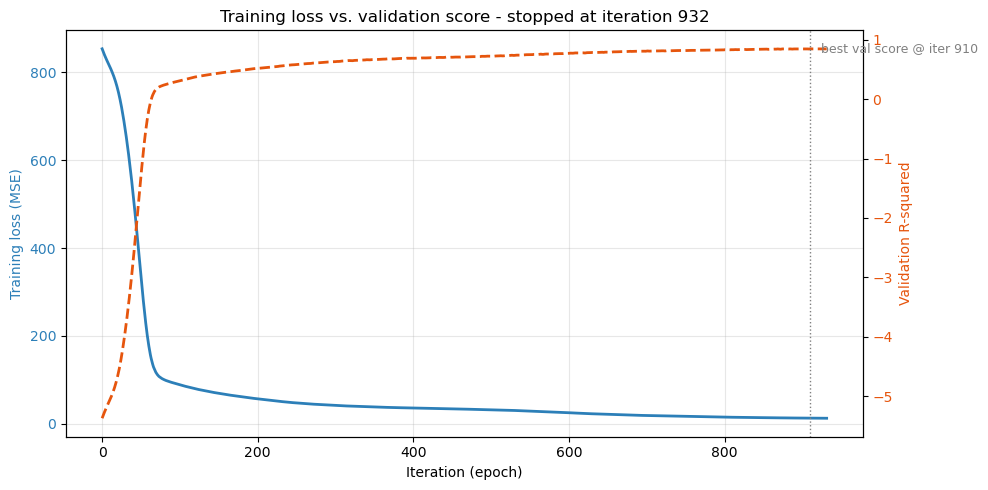

Stopped at iteration: 932  (max_iter cap was 5000)
Best validation R-squared: 0.8470 at iteration 910
Final training loss:        12.7256
  -> Early stopping kicked in. The model rolled back to its best weights.
  -> Saved roughly 4068 iterations of pointless training.


In [7]:
# Plot training loss AND validation score on the same figure.
# Two y-axes because they're different units:
#   - Training loss is mean squared error (smaller = better)
#   - Validation score is R-squared (bigger = better, capped at 1.0)

fig, ax_loss = plt.subplots(figsize=(10, 5))

# Left axis: training loss
ax_loss.plot(nnModel.loss_curve_, color='#2c7fb8', linewidth=2, label='Training loss (MSE)')
ax_loss.set_xlabel('Iteration (epoch)')
ax_loss.set_ylabel('Training loss (MSE)', color='#2c7fb8')
ax_loss.tick_params(axis='y', labelcolor='#2c7fb8')
ax_loss.grid(alpha=0.3)

# Right axis: validation R-squared (twin axis sharing the x)
ax_score = ax_loss.twinx()
ax_score.plot(nnModel.validation_scores_, color='#e6550d', linewidth=2,
              linestyle='--', label='Validation R-squared')
ax_score.set_ylabel('Validation R-squared', color='#e6550d')
ax_score.tick_params(axis='y', labelcolor='#e6550d')

# Mark where the best validation score was reached
best_iter = int(np.argmax(nnModel.validation_scores_))
ax_score.axvline(best_iter, color='gray', linestyle=':', linewidth=1)
ax_score.annotate(f'best val score @ iter {best_iter}',
                  xy=(best_iter, nnModel.best_validation_score_),
                  xytext=(8, 0), textcoords='offset points',
                  va='center', fontsize=9, color='gray')

plt.title(f'Training loss vs. validation score - stopped at iteration {nnModel.n_iter_}')
fig.tight_layout()
plt.show()

# Convergence sanity check
print(f"Stopped at iteration: {nnModel.n_iter_}  (max_iter cap was {nnModel.max_iter})")
print(f"Best validation R-squared: {nnModel.best_validation_score_:.4f} at iteration {best_iter}")
print(f"Final training loss:        {nnModel.loss_:.4f}")

if nnModel.n_iter_ >= nnModel.max_iter:
    print("  -> Hit the max_iter cap. Loss may still be dropping. Consider raising max_iter.")
else:
    print("  -> Early stopping kicked in. The model rolled back to its best weights.")
    print(f"  -> Saved roughly {nnModel.max_iter - nnModel.n_iter_} iterations of pointless training.")


### Part 5: Evaluate the Neural Network

In [8]:
# Make predictions on test set (remember: use SCALED test data)
nnPredictions = nnModel.predict(X_test_scaled)

# Calculate performance metrics
nnR2 = r2_score(y_test, nnPredictions)
nnMAE = mean_absolute_error(y_test, nnPredictions)

print("Neural Network Performance:")
print(f"  R² Score: {nnR2:.4f}")
print(f"    (Interpretation: Explains {nnR2*100:.1f}% of variance in strength)")
print(f"  Mean Absolute Error: {nnMAE:.2f} MPa")
print(f"    (On average, predictions are off by {nnMAE:.1f} MPa)")

Neural Network Performance:
  R² Score: 0.8544
    (Interpretation: Explains 85.4% of variance in strength)
  Mean Absolute Error: 4.76 MPa
    (On average, predictions are off by 4.8 MPa)


### Part 6: Compare to Linear Regression

Neural networks are powerful, but are they better than simpler models for this problem? Let's test the same question we asked about the weather data last lesson.

In [9]:
# Build a Linear Regression model for comparison
# Note: Linear Regression does NOT need scaling
lrModel = LinearRegression()
lrModel.fit(X_train, y_train)  # use UNSCALED training data
lrPredictions = lrModel.predict(X_test)  # use UNSCALED test data

# Calculate Linear Regression metrics
lrR2 = r2_score(y_test, lrPredictions)
lrMAE = mean_absolute_error(y_test, lrPredictions)

print("Linear Regression Performance:")
print(f"  R² Score: {lrR2:.4f}")
print(f"  Mean Absolute Error: {lrMAE:.2f} MPa")

Linear Regression Performance:
  R² Score: 0.6276
  Mean Absolute Error: 7.75 MPa


In [10]:
# Side-by-side comparison
print("\n" + "="*55)
print("COMPARISON: Linear Regression vs Neural Network")
print("="*55)
print(f"{'Model':<25} {'R² Score':<15} {'MAE (MPa)':<10}")
print("-" * 55)
print(f"{'Linear Regression':<25} {lrR2:<15.4f} {lrMAE:<10.2f}")
print(f"{'Neural Network (32-16)':<25} {nnR2:<15.4f} {nnMAE:<10.2f}")
print("="*55)

if nnR2 > lrR2:
    improvement = ((nnR2 - lrR2) / lrR2) * 100
    print(f"\nNeural Network improved R² by {improvement:.1f}%")
elif lrR2 > nnR2:
    improvement = ((lrR2 - nnR2) / nnR2) * 100
    print(f"\nLinear Regression outperformed by {improvement:.1f}%")
else:
    print(f"\nBoth models perform equally!")


COMPARISON: Linear Regression vs Neural Network
Model                     R² Score        MAE (MPa) 
-------------------------------------------------------
Linear Regression         0.6276          7.75      
Neural Network (32-16)    0.8544          4.76      

Neural Network improved R² by 36.1%


### Part 7: Interpretation and Insights

**What just happened?**

The neural network should have beaten linear regression on this dataset — often by a big margin (typically more than 0.25 R² points). Here's why:

1. **Concrete strength is genuinely nonlinear.** Strength grows roughly like the *logarithm* of curing age — fast at first, then slowly. Linear regression can only draw straight lines, so it can't capture "fast then slow."

2. **Ingredients interact.** A little more cement *with* a little more water behaves differently than either change alone. Linear regression assumes each feature acts independently; neural networks learn interactions automatically.

3. **The water-to-cement ratio matters, not just water alone.** Linear regression can't discover ratios from raw columns — it treats water and cement as two separate additive effects. A neural network can learn the interaction.

**Compare this to the weather dataset from Lesson 06:**
- Max temperature from min temperature, humidity, wind → mostly linear → LR won.
- Concrete strength from 8 ingredients + age → nonlinear → NN wins.

**The lesson:** The best model depends on the *shape* of the relationship in your data. Neural networks earn their keep when relationships curve, interact, or depend on ratios. When the world is actually linear, linear regression wins on simplicity.

**When Neural Networks Shine:**
- **Nonlinear patterns** like concrete strength, biology, physics
- **Interactions between features** that simple models can't capture
- **Images:** CNNs with thousands of features
- **Text:** RNNs and Transformers with language patterns
- **Large datasets:** thousands to millions of examples

**When Linear Regression is Better:**
- Actually linear relationships (many real problems!)
- Interpretable: "Each extra kg of cement adds X MPa of strength"
- Less data needed
- Faster to train
- No scaling required

**Bottom Line:** Try the simplest model first. Upgrade to a neural network only when the simpler model leaves real accuracy on the table — like it did here.

---

### Part 8: Try This — Experiment with Architecture

Try changing the architecture to see how it affects performance:

## Summary

**What You Learned:**

- How artificial neurons work and why they need weights
- Neural network architecture (input, hidden, output layers)
- Forward pass and backpropagation (conceptually)
- Why scaling data is critical for neural networks
- How to build a neural network in scikit-learn
- How a **validation set** lets us watch for overfitting *during* training
- How **early stopping** halts training when the model stops improving and rolls back to the best weights
- How to plot and read a training loss + validation score curve together
- How to compare neural networks to linear regression
- When to choose which model

**Key Takeaways:**
- Neural networks learn from data by adjusting many small weights
- Scaling features with StandardScaler is essential
- The validation set is carved out of training data — your test set stays untouched
- **Always check the loss + validation curves** — divergence means overfitting; flat means converged
- Early stopping prevents wasted training and overfitting in one move
- Neural networks beat linear regression when relationships are nonlinear (concrete)
- Linear regression wins when relationships are actually linear (weather)
- Always evaluate multiple models on the same problem!
